# Support Integrity Auditor (SIA) - Full Reproducible Pipeline

This notebook demonstrates the complete pipeline:

1. Dataset loading
2. Exploratory data analysis
3. Self-supervised pseudo-label generation
4. Model training
5. Evaluation
6. Inference with Evidence Dossier

In [27]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/customer_support_tickets.csv")
df.head()

,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score
0,TKT-100000,George Simon,lisastrickland@example.com,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,2025-07-02,43,David Kim,5
1,TKT-100001,Scott Thompson,wevans@example.org,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,2025-06-28,41,Elena Rodriguez,5
2,TKT-100002,Jennifer Smith,oleonard@example.net,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,2025-02-05,7,Anya Sharma,5
3,TKT-100003,Rachel Bullock,katherine67@example.net,Login failed - Let,"Hi Support, The dashboard is not loading any d...",Technical,Low,Web Form,2025-03-20,41,Anya Sharma,5
4,TKT-100004,Thomas Parks DDS,raykelsey@example.com,Refund status - Attention,"Hi Support, I have been trying to update my pa...",Billing,Medium,Email,2025-04-27,40,David Kim,5


In [28]:
df.shape, df.columns.tolist()

((20000, 12),
 ['Ticket_ID',
  'Customer_Name',
  'Customer_Email',
  'Ticket_Subject',
  'Ticket_Description',
  'Issue_Category',
  'Priority_Level',
  'Ticket_Channel',
  'Submission_Date',
  'Resolution_Time_Hours',
  'Assigned_Agent',
  'Satisfaction_Score'])

In [29]:
df["Priority_Level"].value_counts()

Priority_Level
Low         7716
Medium      7570
High        3416
Critical    1298
Name: count, dtype: int64

In [30]:
df["Issue_Category"].value_counts()

Issue_Category
Technical          5918
Billing            5036
Account            4081
General Inquiry    3925
Fraud              1040
Name: count, dtype: int64

## Exploratory Data Analysis

In [31]:
print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (20000, 12)

Missing Values:
Ticket_ID                0
Customer_Name            0
Customer_Email           0
Ticket_Subject           0
Ticket_Description       0
Issue_Category           0
Priority_Level           0
Ticket_Channel           0
Submission_Date          0
Resolution_Time_Hours    0
Assigned_Agent           0
Satisfaction_Score       0
dtype: int64


<Axes: xlabel='Priority_Level'>

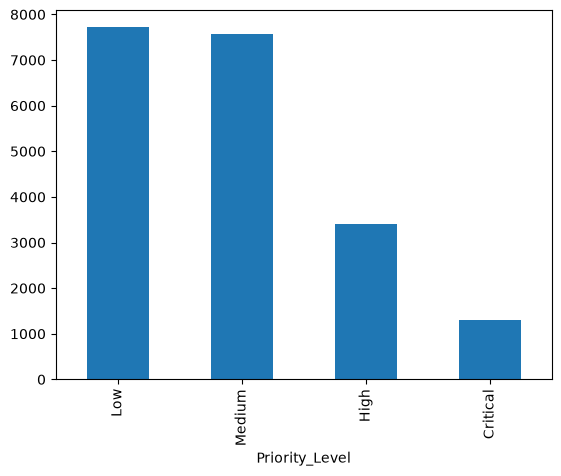

In [32]:
df["Priority_Level"].value_counts().plot(kind="bar")

<Axes: xlabel='Issue_Category'>

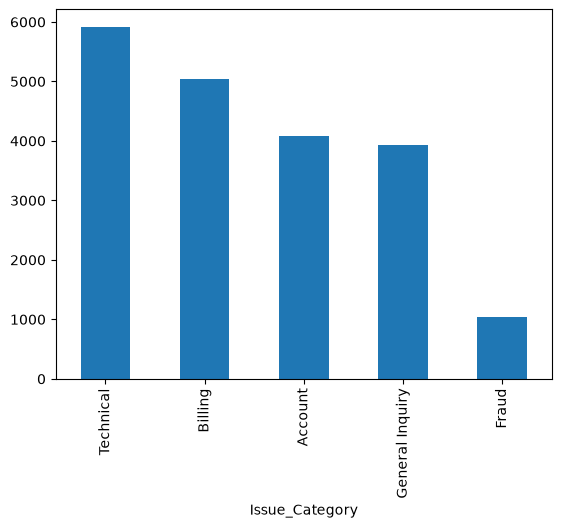

In [33]:
df["Issue_Category"].value_counts().plot(kind="bar")

## Self-Supervised Pseudo Label Generation

In [34]:
category_scores = {
    "General Inquiry": 20,
    "Account": 50,
    "Billing": 60,
    "Technical": 75,
    "Fraud": 90
}

priority_map = {
    "Low": 1,
    "Medium": 2,
    "High": 3,
    "Critical": 4
}

In [35]:
urgent_keywords = {
    "failed": 20,
    "failing": 20,
    "cannot": 20,
    "unable": 20,
    "not loading": 25,
    "crashes": 25,
    "crash": 25,
    "password": 15,
    "login": 20,
    "payment": 20,
    "refund": 15,
    "fraud": 35,
    "locked": 25,
    "error": 20,
    "data not syncing": 25,
    "subscription": 10,
    "2fa": 20
}

In [36]:
def resolution_score(hours):
    if hours <= 12:
        return 20
    elif hours <= 24:
        return 40
    elif hours <= 48:
        return 60
    elif hours <= 72:
        return 80
    else:
        return 100

def text_urgency_score(subject, description):
    text = f"{subject} {description}".lower()
    score = 0
    matched = []

    for keyword, weight in urgent_keywords.items():
        if keyword in text:
            score += weight
            matched.append(keyword)

    return min(score, 100), ", ".join(matched)

def infer_severity(score):
    if score < 30:
        return "Low"
    elif score < 55:
        return "Medium"
    elif score < 75:
        return "High"
    else:
        return "Critical"

In [37]:
df["Category_Score"] = df["Issue_Category"].map(category_scores)
df["Resolution_Score"] = df["Resolution_Time_Hours"].apply(resolution_score)

text_results = df.apply(
    lambda row: text_urgency_score(row["Ticket_Subject"], row["Ticket_Description"]),
    axis=1
)

df["Text_Urgency_Score"] = text_results.apply(lambda x: x[0])
df["Matched_Keywords"] = text_results.apply(lambda x: x[1])

df["Severity_Score"] = (
    0.35 * df["Category_Score"] +
    0.35 * df["Resolution_Score"] +
    0.30 * df["Text_Urgency_Score"]
)

df["Inferred_Severity"] = df["Severity_Score"].apply(infer_severity)
df["Mismatch_Label"] = (df["Priority_Level"] != df["Inferred_Severity"]).astype(int)

In [38]:
df[[
    "Ticket_ID",
    "Priority_Level",
    "Inferred_Severity",
    "Severity_Score",
    "Matched_Keywords",
    "Mismatch_Label"
]].head(10)

,Ticket_ID,Priority_Level,Inferred_Severity,Severity_Score,Matched_Keywords,Mismatch_Label
0,TKT-100000,High,Low,28.00,,1
1,TKT-100001,High,High,69.75,"crashes, crash, data not syncing",0
2,TKT-100002,High,Medium,30.50,2fa,1
3,TKT-100003,Low,High,66.75,"failed, not loading, login",1
4,TKT-100004,Medium,High,58.50,"failing, payment, refund",1
5,TKT-100005,Medium,Low,21.00,,1
6,TKT-100006,Medium,High,57.00,password,1
7,TKT-100007,Medium,High,57.00,"failed, payment, subscription",1
8,TKT-100008,High,Critical,76.75,"failed, cannot, password, login",1
9,TKT-100009,Low,Medium,42.00,,1


## Model Training and Evaluation

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [40]:
df["Combined_Text"] = df["Ticket_Subject"].fillna("") + " " + df["Ticket_Description"].fillna("")

X = df[[
    "Combined_Text",
    "Issue_Category",
    "Ticket_Channel",
    "Resolution_Time_Hours",
    "Satisfaction_Score"
]]

y = df["Mismatch_Label"]

In [41]:
preprocessor = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(max_features=5000, ngram_range=(1, 2)), "Combined_Text"),
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["Issue_Category", "Ticket_Channel"]),
        ("num", StandardScaler(), ["Resolution_Time_Hours", "Satisfaction_Score"]),
    ]
)

model = LogisticRegression(
    max_iter=3000,
    solver="liblinear",
    class_weight="balanced"
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6005
Macro F1: 0.5816069383079693

Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.60      0.49      1288
           1       0.76      0.60      0.67      2712

    accuracy                           0.60      4000
   macro avg       0.59      0.60      0.58      4000
weighted avg       0.65      0.60      0.61      4000


Confusion Matrix:
[[ 776  512]
 [1086 1626]]


## Inference and Evidence Dossier

In [43]:
sample = X_test.iloc[0:1]
prediction = pipeline.predict(sample)[0]
confidence = pipeline.predict_proba(sample)[0][prediction]

print("Prediction:", "Mismatch" if prediction == 1 else "Consistent")
print("Confidence:", round(float(confidence), 3))

Prediction: Mismatch
Confidence: 0.707


In [44]:
sample_ticket = df.loc[X_test.index[0]]

dossier = {
    "ticket_id": sample_ticket["Ticket_ID"],
    "assigned_priority": sample_ticket["Priority_Level"],
    "inferred_severity": sample_ticket["Inferred_Severity"],
    "mismatch_type": "Hidden Crisis" if sample_ticket["Mismatch_Label"] == 1 else "Consistent",
    "severity_delta": priority_map[sample_ticket["Inferred_Severity"]] - priority_map[sample_ticket["Priority_Level"]],
    "feature_evidence": [
        {
            "signal": "keyword",
            "value": sample_ticket["Matched_Keywords"],
            "weight": "high" if sample_ticket["Matched_Keywords"] else "low"
        },
        {
            "signal": "resolution_time",
            "value": f'{sample_ticket["Resolution_Time_Hours"]} hours',
            "interpretation": "Used as severity proxy"
        }
    ],
    "constraint_analysis": "All evidence is derived directly from fields in the input ticket.",
    "confidence": round(float(confidence), 3)
}

dossier

{'ticket_id': 'TKT-107798',
 'assigned_priority': 'Low',
 'inferred_severity': 'Medium',
 'mismatch_type': 'Hidden Crisis',
 'severity_delta': 1,
 'feature_evidence': [{'signal': 'keyword',
   'value': 'cannot, 2fa',
   'weight': 'high'},
  {'signal': 'resolution_time',
   'value': '34 hours',
   'interpretation': 'Used as severity proxy'}],
 'constraint_analysis': 'All evidence is derived directly from fields in the input ticket.',
 'confidence': 0.707}

In [45]:
sample_ticket = df.loc[X_test.index[0]]

dossier = {
    "ticket_id": sample_ticket["Ticket_ID"],
    "assigned_priority": sample_ticket["Priority_Level"],
    "inferred_severity": sample_ticket["Inferred_Severity"],
    "mismatch_type": "Hidden Crisis" if sample_ticket["Mismatch_Label"] == 1 else "Consistent",
    "severity_delta": priority_map[sample_ticket["Inferred_Severity"]] - priority_map[sample_ticket["Priority_Level"]],
    "feature_evidence": [
        {
            "signal": "keyword",
            "value": sample_ticket["Matched_Keywords"],
            "weight": "high" if sample_ticket["Matched_Keywords"] else "low"
        },
        {
            "signal": "resolution_time",
            "value": f'{sample_ticket["Resolution_Time_Hours"]} hours',
            "interpretation": "Used as severity proxy"
        }
    ],
    "constraint_analysis": "All evidence is derived directly from fields in the input ticket.",
    "confidence": round(float(confidence), 3)
}

dossier

{'ticket_id': 'TKT-107798',
 'assigned_priority': 'Low',
 'inferred_severity': 'Medium',
 'mismatch_type': 'Hidden Crisis',
 'severity_delta': 1,
 'feature_evidence': [{'signal': 'keyword',
   'value': 'cannot, 2fa',
   'weight': 'high'},
  {'signal': 'resolution_time',
   'value': '34 hours',
   'interpretation': 'Used as severity proxy'}],
 'constraint_analysis': 'All evidence is derived directly from fields in the input ticket.',
 'confidence': 0.707}